In [ ]:
from conf.default import get_cfg_defaults
from Noise2Model.data import preprocessing, get_png_img_paths, parse_file_name
from Noise2Model.trainer import get_trainer_class

In [ ]:
!gpustat

In [ ]:
from torch.cuda import is_available
print(is_available())

In [ ]:
img_path = '../../_data/04-mito-20x-noise1/'

In [ ]:
img_paths = get_png_img_paths(img_path)[:1]

for img_idx, imgpath in enumerate((img_paths)):
    print(f'Processing image {img_idx+1}/{len(img_paths)}: {imgpath}')

In [ ]:
parse_file_name(imgpath)

In [ ]:
preprocessing(img_path,
              output_base_path='../../_data/HDF5_04-mito-20x-noise1_s96_o08', 
              get_img_paths_func=get_png_img_paths,
              parse_config=parse_file_name,
              train_noisegen_idx=[i for i in range(1,10)],
              test_idx=[99],
              overwrite=True,)

In [ ]:
from Noise2Model.data import load_and_display_hdf5_image

../../_data/HDF5_04-mito-20x-noise1_s96_o08/noise_gen/test/0088_GT.hdf5
(1, 96, 96)


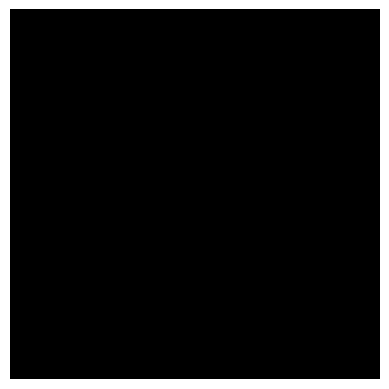

In [ ]:
output_base_path = '../../_data/HDF5_04-mito-20x-noise1_s96_o08'
file_path = output_base_path + '/noise_gen/test/0088_GT.hdf5'
print(file_path)
load_and_display_hdf5_image(file_path, dataset_name='clean', patch_num=1)

In [ ]:
device = '1'

config = get_cfg_defaults()
config.merge_from_file('../../conf/NMFlowGAN_NoiseModeler5.yaml')


In [ ]:
# intialize trainer
trainer = get_trainer_class(config.BASE.trainer)(config)
trainer.set_device(device)
trainer.train()
